In [345]:
import numpy as np
import matplotlib.pyplot as plt


## -- Step 1: Завантаження зображень --

img1_raw shape: (249, 249, 3)
img2_raw shape: (325, 600, 3)


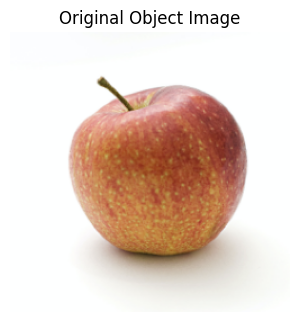

In [346]:
# img1_path = 'natural-composition-with-two-pink-flowers-floral-hearts_23-2147601167.jpg'     # Об'єкт на однорідному фоні
img1_path = 'test.PNG' 
img2_path = 'Background.webp' # Фон

def to_rgb(img):
   if img.shape[-1] == 4:
       return img[:, :, :3]
   return img

def normalize_img(img):
    """Приводить до uint8 з діапазоном 0-255"""
    if img.dtype == np.float32 or img.dtype == np.float64:
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
    return img

img1_raw = normalize_img(to_rgb(plt.imread(img1_path)))
img2_raw = normalize_img(to_rgb(plt.imread(img2_path)))


plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(img1_raw)
plt.title("Original Object Image")
plt.axis('off')

print("img1_raw shape:", img1_raw.shape)
print("img2_raw shape:", img2_raw.shape)

## --Step 2: Обрізка об'єкта --

In [347]:
# (коригуй координати під своє зображення)
img1 = img1_raw[60:260, 120:408, :]
# img1 = img1_raw [100:220, 220:338, :]

####  Якщо зображення має 4 канали (RGBA), обрізаємо альфа-канал

## Step 3: Конвертація в grayscale 

(np.float64(-0.5), np.float64(128.5), np.float64(188.5), np.float64(-0.5))

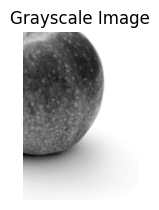

In [348]:
def rgb2gray_1(img_rgb):
    """Перевід RGB в grayscale вручну"""
    return (0.299 * img_rgb[:, :, 0] +
            0.587 * img_rgb[:, :, 1] +
            0.114 * img_rgb[:, :, 2])

img_gray = rgb2gray_1(img1)

plt.subplot(2, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

## Step 4: Метод Отсу (Otsu) 

In [349]:
def otsu_threshold(image):
    """Метод Отсу для знаходження порогу бінаризації"""
    pixel_counts, bin_edges = np.histogram(image.ravel(), bins=256, range=(0, 255))
    total = image.size
    current_max, threshold = 0, 0
    sum_total = np.dot(np.arange(256), pixel_counts)
    sumB, wB = 0.0, 0.0

    for t in range(256):
        wB += pixel_counts[t]
        if wB == 0:
            continue
        wF = total - wB
        if wF == 0:
            break
        sumB += t * pixel_counts[t]
        mB = sumB / wB
        mF = (sum_total - sumB) / wF
        between_var = wB * wF * (mB - mF) ** 2
        if between_var > current_max:
            current_max = between_var
            threshold = t
    return threshold

threshold = otsu_threshold(img_gray)
print("Otsu Threshold:", threshold)

Otsu Threshold: 178


## Step 5: Бінаризація

(189, 129, 3) uint8


(np.float64(-0.5), np.float64(128.5), np.float64(188.5), np.float64(-0.5))

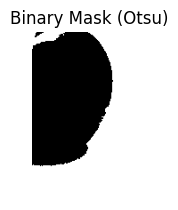

In [350]:
img_mask = binarization_global(img_gray, threshold)



# Маска shape: (H, W) => розширюємо для RGB
img_mask_rgb = np.stack([img_mask]*3, axis=-1)

img_mask_rgb = np.stack([img_mask]*3, axis=-1)
img_object = np.where(img_mask_rgb == 1, img1, 0)

# Виділяємо об'єкт

print(img_object.shape, img_object.dtype)

plt.subplot(2, 2, 3)
plt.imshow(img_mask, cmap='gray')
plt.title("Binary Mask (Otsu)")
plt.axis('off')

## Step 6: Вирізання об'єкта

In [351]:
# Додаємо третю координату до маски (для RGB)
img_object = img1 * img_mask[:, :, None]

## Step 7: Додавання об'єкта на фон

In [ ]:
# --- Вихідне зображення-фон
result = img2_raw.copy()

# --- Розміри об'єкта
h, w = img_object.shape[:2]

# --- Зсув (координати, куди вставляти об'єкт)
y_offset = 100
x_offset = 200

# --- Вставляємо пікселі вручну
for y in range(h):
    for x in range(w):
        if img_mask[y, x] == 1:
            # Перевіряємо чи в межах фону
            if (0 <= y + y_offset < result.shape[0]) and (0 <= x + x_offset < result.shape[1]):
                result[y + y_offset, x + x_offset] = img_object[y, x][:3]  # вставляємо RGB


<Figure size 640x480 with 0 Axes>

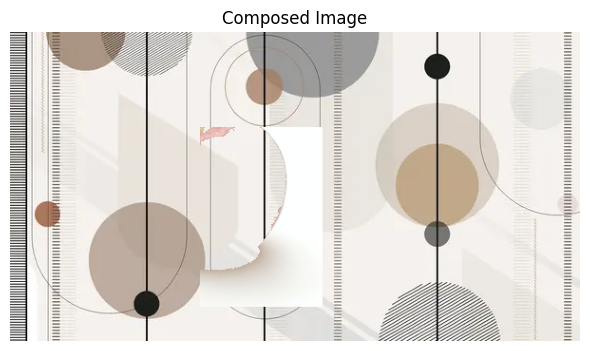

In [352]:
def compose(background, object_img, mask, y_offset, x_offset):
    """Накладання ob'єкта на фон"""
    h, w = object_img.shape[:2]
    composed = background.copy()
    for y in range(h):
        for x in range(w):
            if mask[y, x] == 1:
                if (0 <= y + y_offset < composed.shape[0]) and (0 <= x + x_offset < composed.shape[1]):
                    composed[y + y_offset, x + x_offset] = object_img[y, x][:3]  # гарантовано RGB
    return composed


result = compose (img2_raw, img_object, img_mask, y_offset=100, x_offset=200)

plt.tight_layout()
plt.savefig("results.png")
plt.show()


plt.figure(figsize=(6, 6))
plt.imshow(result)
plt.title("Composed Image")
plt.axis('off')
plt.tight_layout()
plt.savefig("result_composed.png")
plt.show()
